# Module 04 Lab - Exploratory Data Analysis**Objective:** To learn how to explore a dataset to find patterns, anomalies, and insights before modeling. EDA is like being a detective; you are looking for clues in the data that will help you build a better model.**This lab is fully coded.** Your task is to run each cell, read the detailed explanations, understand the purpose of each visualization, and then complete the experimentation section.

## Part 1: Setup and Data Loading**What is Exploratory Data Analysis (EDA)?**EDA is the process of using summary statistics and visualizations to understand a dataset's main characteristics. Before you can build a model, you need to understand your data. What stories does it tell? Are there errors or missing values? Are there strong relationships between variables? EDA helps answer these questions.We will use the famous Titanic dataset for this lab. It contains information about passengers and, crucially, whether they survived the disaster.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn is built on top of Matplotlib and provides
# more attractive default visualizations.

# Load the Titanic dataset from GitHub
df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Basic Info ---")

# .info() provides:
# - column names
# - number of non-null values
# - data types
# - memory usage
#
# This is often one of the first EDA commands you run
# because it quickly reveals:
# - missing values
# - unexpected data types
# - dataset dimensions
#
# For example:
# - 'Age' contains missing values
# - 'Cabin' contains many missing values
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

In [2]:
# Number of rows with at least one missing value
rows_with_missing = df.isnull().any(axis=1).sum()

# Total number of rows
total_rows = len(df)

# Percentage of rows with missing values
pct_missing_rows = (rows_with_missing / total_rows) * 100

print(f"Rows with missing values: {rows_with_missing}")
print(f"Percentage of rows with missing values: {pct_missing_rows:.2f}%")

Rows with missing values: 708
Percentage of rows with missing values: 79.46%


## Part 2: Descriptive StatisticsLet's start by getting a high-level numerical summary of the data. The `.describe()` method is perfect for this. It calculates statistics like mean, standard deviation, min, and max for the numerical columns.

In [3]:
# Get summary statistics for numerical columns
print("--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Key Insights from Statistics ---")

# Average passenger age
print(
    f"The average age of a passenger was "
    f"{df['Age'].mean():.1f} years."
)

# Survival rate
print(
    f"The overall survival rate was "
    f"{df['Survived'].mean():.1%}."
)

# Fare range
print(
    f"Fares ranged from "
    f"${df['Fare'].min():.2f} "
    f"to a whopping "
    f"${df['Fare'].max():.2f}."
)

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

--- Key Insights from Statistics ---
The average 

## Part 3: Visual EDA - Telling Stories with PlotsNumbers are great, but plots make patterns and relationships immediately obvious. The goal of visual EDA is to turn data into insights.**A Note on Plotting Libraries:***   **Matplotlib:** The foundational library, gives you full control over everything.*   **Seaborn:** Built on Matplotlib, it provides a simpler, high-level interface for creating common statistical plots. We will use Seaborn for its ease of use and attractive defaults.

### Visualization 1: How many survived?A simple `countplot` is the best way to see the distribution of a categorical variable, like our target `Survived`.

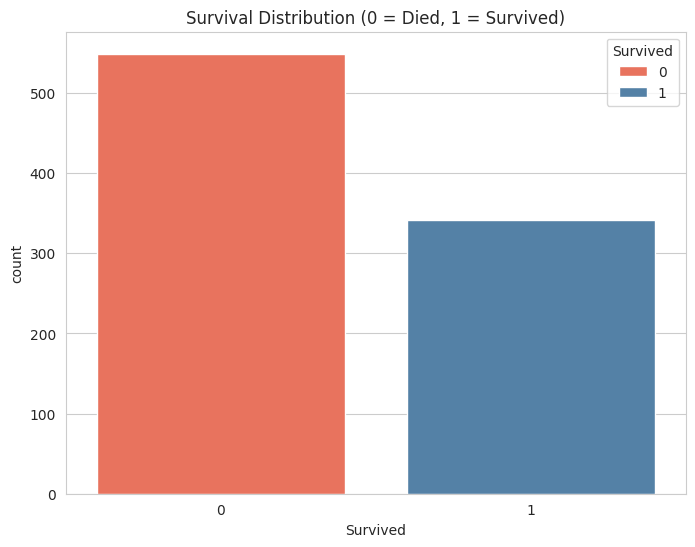

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [4]:
#import matplotlib.pyplot as plt
#import seaborn as sns

sns.set_style('whitegrid')  # Sets a nice visual style for our plots

plt.figure(figsize=(8, 6))
sns.countplot(x='Survived',hue='Survived', data=df, palette=['tomato', 'steelblue'])

plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()

print(
    "Insight: Far more people died than survived. "
    "This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models."
)

### Visualization 2: Does passenger class matter for survival?Now we want to see if there's a relationship between two variables. We can use the `hue` parameter in `countplot` to split the bars by another category.

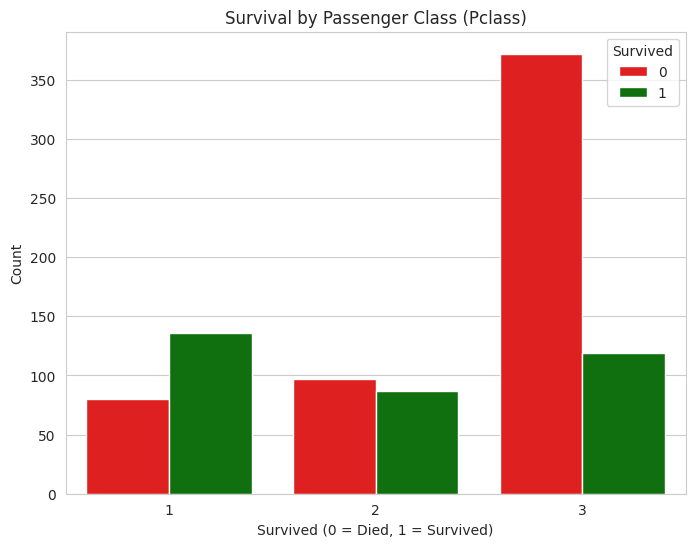

Insight: Passenger class strongly affects survival. 1st class passengers had higher survival rates, while 3rd class passengers made up most of the deaths.


In [6]:
# Apply a clean visual theme to all plots
sns.set_style("whitegrid")

# Create the figure and set its size
plt.figure(figsize=(8, 6))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df,
    palette=["red", "green"]
)

# Title and labels
plt.title("Survival by Passenger Class (Pclass)")
plt.xlabel("Survived (0 = Died, 1 = Survived)")
plt.ylabel("Count")

# Display the plot
plt.show()

# Interpretation
print(
    "Insight: Passenger class strongly affects survival. "
    "1st class passengers had higher survival rates, "
    "while 3rd class passengers made up most of the deaths."
)

### Visualization 3: What about gender?The 'women and children first' mantra is famous. Let's see if the data supports it.

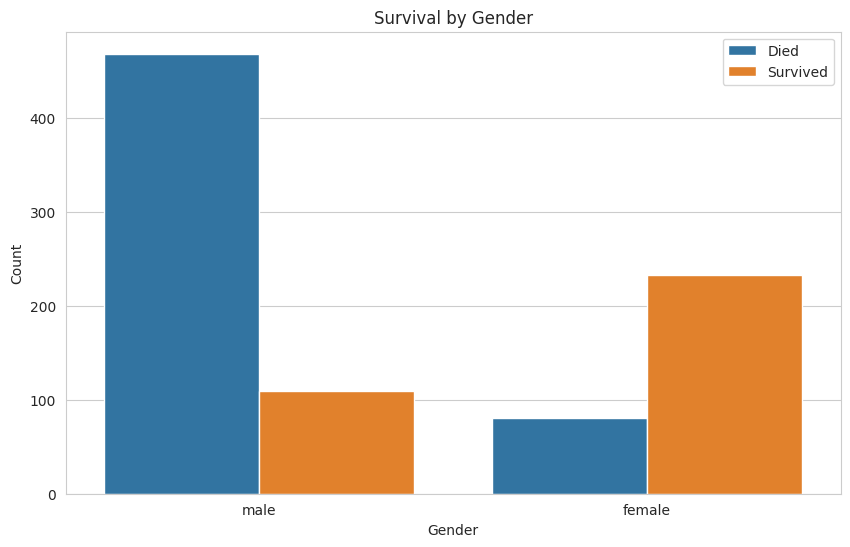

Insight: The pattern is very clear. A much higher proportion of females survived compared to males. This suggests gender is a very strong predictor of survival.


In [7]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Countplot: survival breakdown by gender
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

# Title
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

# Legend labels (0 = Died, 1 = Survived)
plt.legend(["Died", "Survived"])
#plt.legend(title="Survived")

# Show plot
plt.show()

# Insight interpretation
print(
    "Insight: The pattern is very clear. "
    "A much higher proportion of females survived compared to males. "
    "This suggests gender is a very strong predictor of survival."
)

### Visualization 4: How does age play a role?For a continuous variable like `Age`, a histogram is a great way to see its distribution.

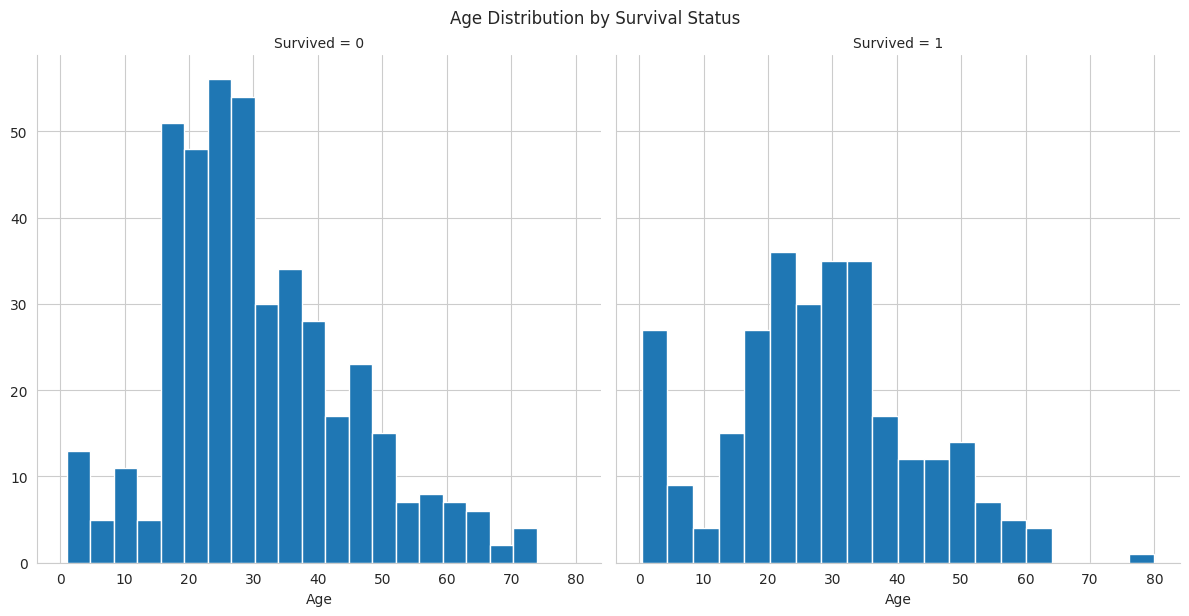

Insight: The age distribution for those who did not survive is centered around the 20–40 age range. For those who survived, there is a noticeable spike for young children. This supports the idea that children had a higher chance of survival.


In [8]:
# Create FacetGrid: separate plots for Survived = 0 and Survived = 1
g = sns.FacetGrid(df, col="Survived", height=6)

# Map histogram of Age onto each subplot
g.map(plt.hist, "Age", bins=20)

# Add overall title (optional improvement)
g.fig.suptitle("Age Distribution by Survival Status", y=1.02)

plt.show()

# Insight interpretation
print(
    "Insight: The age distribution for those who did not survive is centered "
    "around the 20–40 age range. For those who survived, there is a noticeable "
    "spike for young children. This supports the idea that children had a higher "
    "chance of survival."
)

## Part 4: Student Experimentation**Instructions:** Create your own visualizations to explore other relationships in the data.

### Experiment 1: Port of Embarkation1.  The `Embarked` column tells you where a passenger boarded the ship (C = Cherbourg, Q = Queenstown, S = Southampton).2.  Create a `countplot` to see how survival rates differed by the port of embarkation. Does where they boarded seem to be related to their survival?

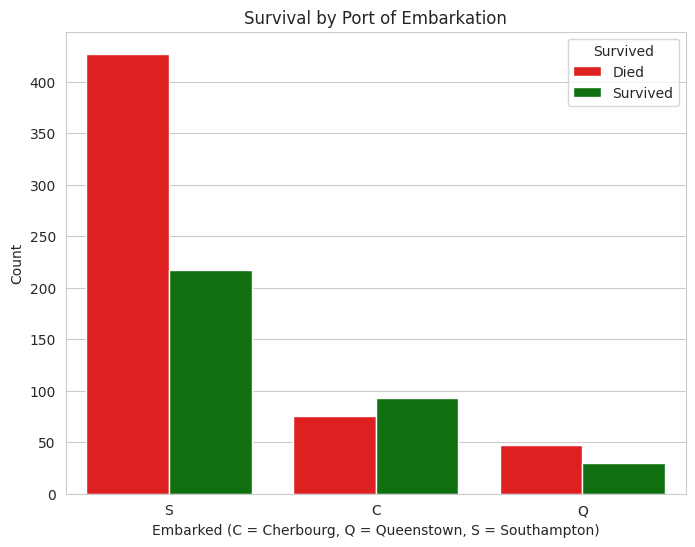

Insight: Boarding at Southampton saw the highest total volume
of passengers and casualties, Cherbourg was the only
embarkation point where survivors outnumbered the deceased. Boarding at Southampton
seems to be somewhat of a death knell.


In [9]:
# Clean visual style
sns.set_style("whitegrid")

# Plot size
plt.figure(figsize=(8, 6))

# Countplot: survival by port of embarkation
sns.countplot(
    x="Embarked",
    hue="Survived",
    data=df,
    palette=["red", "green"]
)

# Labels and title
plt.title("Survival by Port of Embarkation")
plt.xlabel("Embarked (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Count")

plt.legend(title="Survived", labels=["Died", "Survived"])

plt.show()

# Interpretation
print(
    "Insight: Boarding at Southampton saw the highest total volume\n"
    "of passengers and casualties, Cherbourg was the only\n"
    "embarkation point where survivors outnumbered the deceased. Boarding at Southampton\n"
    "seems to be somewhat of a death knell."
)

### Experiment 2: Fare vs. Survival1.  `Fare` is a continuous numerical variable.2.  A `boxplot` or `violinplot` is a great way to see the distribution of fares for those who survived vs. those who didn't.3.  Create one of these plots to compare the `Fare` distribution by `Survived`. What does it tell you?

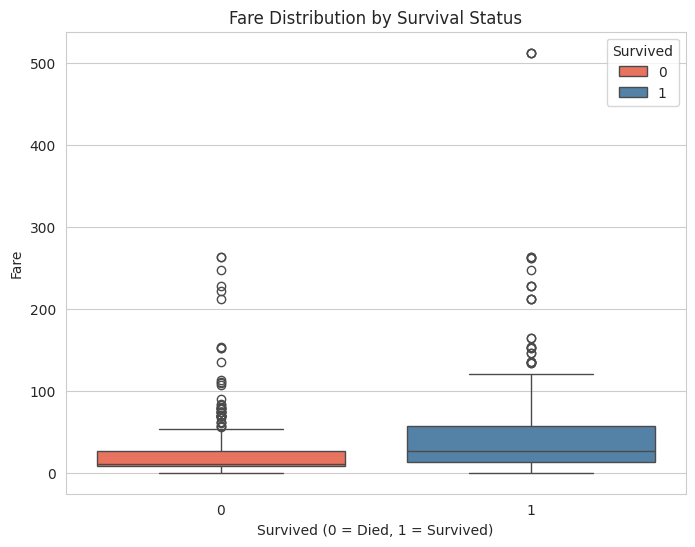

Insight: Deceased passengers were concentrated
in the lowest ticket fare brackets, while those who survived
paid noticeably higher median fares.


In [10]:
plt.figure(figsize=(8, 6))
"""
x = categorical variable (groups)
y = numerical variable (distribution being compared)
hue = another categorical variable that splits each box
"""
sns.boxplot(
    x="Survived",
    y="Fare",
    hue="Survived",
    data=df,
    palette=["tomato", "steelblue"],
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived (0 = Died, 1 = Survived)")
plt.ylabel("Fare")

plt.show()

print(
    "Insight: Deceased passengers were concentrated\n"
    "in the lowest ticket fare brackets, while those who survived\n"
    "paid noticeably higher median fares."
)

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **What is the primary goal of Exploratory Data Analysis (EDA)?**2.  **Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?** (Describe them in terms of class, gender, and age).3.  **Why is it important to visualize data instead of just looking at summary statistics?** What can a plot show you that a number like 'mean' or 'count' can't?
1. The primary goal of EDA is to understand the data's underlying structure, discover patterns, and identify oddities or null values before building models.
2. After considering all the visdual and numerical information generated against the Titanic DataSet during EDA, the data seems to indicate that a  young, female passenger traveling in 1st-class had the best chance of surviving the sinking of the Titanic.
3. Visualizations reveal the actual distribution of the data and highlight outliers that single summary numbers (like a mean or median) can completely hide.